<a href="https://colab.research.google.com/github/egraziani5/egraziani5.github.io/blob/master/Laboratorio_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio di Analisi Numerica
## Lezione 2

Cecilia Pagliantini <cecilia.pagliantini@unipi.it>  
Leonardo Robol <leonardo.robol@unipi.it>  
15 ottobre 2025

> **Quantità di esercizi:** in questa dispensa ci sono *più esercizi* di quanti uno studente medio riesca a farne durante una lezione di laboratorio, specialmente tenendo conto anche degli esercizi facoltativi. Questo perché è pensata per “tenere impegnati” per tutta la lezione anche quegli studenti che già hanno un solido background di programmazione.
>
> Quindi fate gli esercizi che riuscite, partendo da quelli *non* segnati come facoltativi, e non preoccupatevi se non li finite tutti!

Questa lezione usa `LinearAlgebra`, incluso nella libreria standard di Julia, e il pacchetto grafico `Plots`. Se `Plots` non è ancora installato, eseguite una sola volta `using Pkg; Pkg.add("Plots")` in una cella, quindi riavviate il kernel.

In [1]:
using LinearAlgebra
using Random
using Plots

[ Info: Precompiling Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80](cache misses: target mismatch (1))
[ Info: Precompiling Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80] (cache misses: target mismatch (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling IJuliaExt [64482eec-cc57-5312-bea1-9f24eb636db7](cache misses: target mismatch (1))
[ Info: Precompiling IJuliaExt [64482eec-cc57-5312-bea1-9f24eb636db7] (cache misses: target mismatch (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Tas

## 1. Ottenere aiuto

Con la macro `@doc` potete ottenere la documentazione di un comando. In un notebook Julia potete anche scrivere `?imag` in una cella per visualizzare la stessa guida.

In [ ]:
@doc imag

È possibile aggiungere una breve documentazione — ed è buona pratica farlo — anche alle funzioni scritte dall'utente. In Julia si inserisce una *docstring*, racchiusa fra triple virgolette, immediatamente prima della definizione. Provate, ad esempio, a modificare la funzione `pow(x, n)` della lezione precedente in questo modo:

In [2]:
"""
    pow(x, n)

Calcola la potenza `n`-esima del numero floating point `x`.
"""
function pow(x, n)
    # Inserite qui il corpo della funzione scritto nella lezione precedente.
    r = 1.0
    for k in 1:n
    r = r*x
    end
return r
end

pow

Verifichiamo cosa succede richiedendo la documentazione di `pow`:

In [3]:
@doc pow

```julia
pow(x, n)
```

Calcola la potenza `n`-esima del numero floating point `x`.


## 2. Vettori e matrici

Julia è pensato per il calcolo numerico e dispone di una sintassi specifica e di molti comandi dedicati a vettori e matrici, che rendono queste strutture molto più semplici da usare rispetto a un linguaggio generico come il C.

### 2.1. Creare vettori e matrici

In [4]:
A = [1 2 3; 4 5 6]

2×3 Matrix{Int64}:
 1  2  3
 4  5  6

In [5]:
@show zeros(3, 2)
@show ones(3, 2)
@show Matrix{Float64}(I, 3, 3)
@show randn(2, 3);

zeros(3, 2) = [0.0 0.0; 0.0 0.0; 0.0 0.0]
ones(3, 2) = [1.0 1.0; 1.0 1.0; 1.0 1.0]
Matrix{Float64}(I, 3, 3) = [1.0 0.0 0.0; 0.0 1.0 0.0; 0.0 0.0 1.0]
randn(2, 3) = [1.1403178488771946 -0.8838414781563507 0.4514260529736547; -0.08060690329067191 -0.8703156683595419 -0.45227258763065425]


### 2.2. L'operatore di intervallo `:`

Con la sintassi `a:t:b` creiamo un intervallo che contiene gli elementi `a`, `a+t`, `a+2t`, `a+3t`, … fino a `b`, oppure fino all'ultimo elemento minore o uguale a `b`. Se `t=1`, si può semplicemente usare `a:b`. In Julia un intervallo è rappresentato in modo compatto; quando serve esplicitamente un vettore possiamo convertirlo con `collect`.

In [6]:
@show collect(1:0.5:4)
@show collect(1:10)
@show collect(1:2:10);

collect(1:0.5:4) = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
collect(1:10) = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
collect(1:2:10) = [1, 3, 5, 7, 9]


In [48]:
@doc collect


```julia
collect(iterator)
```

Return an `Array` of all items in a collection or iterator. For dictionaries, returns a `Vector` of `key=>value` [Pair](@ref Pair)s. If the argument is array-like or is an iterator with the [`HasShape`](@ref IteratorSize) trait, the result will have the same shape and number of dimensions as the argument.

Used by [comprehensions](@ref man-comprehensions) to turn a [generator expression](@ref man-generators) into an `Array`. Thus, *on generators*, the square-brackets notation may be used instead of calling `collect`, see second example.

The element type of the returned array is based on the types of the values collected. However, if the iterator is empty then the element type of the returned (empty) array is determined by type inference.

# Examples

Collect items from a `UnitRange{Int64}` collection:

```jldoctest
julia> collect(1:3)
3-element Vector{Int64}:
 1
 2
 3
```

Collect items from a generator (same output as `[x^2 for x in 1:3]`):

```jldoctest
julia> collect(x^2 for x in 1:3)
3-element Vector{Int64}:
 1
 4
 9
```

Collecting an empty iterator where the result type depends on type inference:

```jldoctest
julia> [rand(Bool) ? 1 : missing for _ in []]
Union{Missing, Int64}[]
```

When the iterator is non-empty, the result type depends only on values:

```julia-repl
julia> [rand(Bool) ? 1 : missing for _ in [""]]
1-element Vector{Int64}:
 1
```

```julia
collect(element_type, collection)
```

Return an `Array` with the given element type of all items in a collection or iterable. The result has the same shape and number of dimensions as `collection`.

# Examples

```jldoctest
julia> collect(Float64, 1:2:5)
3-element Vector{Float64}:
 1.0
 3.0
 5.0
```


Dove avete già usato l'operatore `:`?

### 2.3. Il comando `range`

In Julia è possibile suddividere un intervallo con il comando `range`. Come il nome suggerisce, permette di dividere un intervallo in parti uguali. Supponiamo, ad esempio, di voler dividere $[0,2\pi]$ in $n-1$ sottointervalli di uguale lunghezza. Possiamo usare `t = range(0, 2π, length=n)` e ottenere un intervallo `t` tale che:

- `t[1] == 0`;
- `t[n] == 2π`;
- per ogni $i$ fra 2 e $n$, `t[i] - t[i-1] == 2π/(n-1)`, a meno degli errori di arrotondamento.

Spesso `range` è il modo più naturale per suddividere un intervallo su cui si desidera disegnare una funzione. Usate `@doc range` per approfondire l'utilizzo del comando.

In [7]:
n = 9
t = range(0, 2π, length=n)

0.0:0.7853981633974483:6.283185307179586

In [8]:
@doc range

```julia
range(start, stop, length)
range(start, stop; length, step)
range(start; length, stop, step)
range(;start, length, stop, step)
```

Construct a specialized array with evenly spaced elements and optimized storage (an [`AbstractRange`](@ref)) from the arguments. Mathematically a range is uniquely determined by any three of `start`, `step`, `stop` and `length`. Valid invocations of range are:

  * Call `range` with any three of `start`, `step`, `stop`, `length`.
  * Call `range` with two of `start`, `stop`, `length`. In this case `step` will be assumed to be positive one. If both arguments are Integers, a [`UnitRange`](@ref) will be returned.
  * Call `range` with one of `stop` or `length`. `start` and `step` will be assumed to be positive one.

To construct a descending range, specify a negative step size, e.g. `range(5, 1; step = -1)` => [5,4,3,2,1]. Otherwise, a `stop` value less than the `start` value, with the default `step` of `+1`, constructs an empty range. Empty ranges are normalized such that the `stop` is one less than the `start`, e.g. `range(5, 1) == 5:4`.

See Extended Help for additional details on the returned type. See also [`logrange`](@ref) for logarithmically spaced points.

# Examples

```jldoctest
julia> range(1, length=100)
1:100

julia> range(1, stop=100)
1:100

julia> range(1, step=5, length=100)
1:5:496

julia> range(1, step=5, stop=100)
1:5:96

julia> range(1, 10, length=101)
1.0:0.09:10.0

julia> range(1, 100, step=5)
1:5:96

julia> range(stop=10, length=5)
6:10

julia> range(stop=10, step=1, length=5)
6:1:10

julia> range(start=1, step=1, stop=10)
1:1:10

julia> range(; length = 10)
Base.OneTo(10)

julia> range(; stop = 6)
Base.OneTo(6)

julia> range(; stop = 6.5)
1.0:1.0:6.0
```

If `length` is not specified and `stop - start` is not an integer multiple of `step`, a range that ends before `stop` will be produced.

```jldoctest
julia> range(1, 3.5, step=2)
1.0:2.0:3.0
```

Special care is taken to ensure intermediate values are computed rationally. To avoid this induced overhead, see the [`LinRange`](@ref) constructor.

!!! compat "Julia 1.1"
    `stop` as a positional argument requires at least Julia 1.1.


!!! compat "Julia 1.7"
    The versions without keyword arguments and `start` as a keyword argument require at least Julia 1.7.


!!! compat "Julia 1.8"
    The versions with `stop` as a sole keyword argument, or `length` as a sole keyword argument require at least Julia 1.8.


# Extended Help

`range` will produce a `Base.OneTo` when the arguments are Integers and

  * Only `length` is provided
  * Only `stop` is provided

`range` will produce a `UnitRange` when the arguments are Integers and

  * Only `start`  and `stop` are provided
  * Only `length` and `stop` are provided

A `UnitRange` is not produced if `step` is provided even if specified as one.

```julia
range(start::T; stop::T, length=100) where T<:Colorant
range(start::T, stop::T; length=100) where T<:Colorant
```

Generates N (=`length`) >2 colors in a linearly interpolated ramp from `start` to `stop`, inclusive, returning an `Array` of colors.

!!! compat "Julia 1.1"
    `stop` as a positional argument requires at least Julia 1.1.



### 2.4. Accedere agli elementi

Julia indicizza vettori e matrici a partire da 1. Per accedere agli elementi si usano le parentesi quadre.

In [9]:
A = ones(2, 3)
A[1, 2] = 2
@show A
@show A[1, 2];

A = [1.0 2.0 1.0; 1.0 1.0 1.0]
A[1, 2] = 2.0


Se proviamo a leggere un elemento che non esiste, otteniamo un `BoundsError`. In Julia anche la scrittura fuori dai limiti produce un errore: le matrici non vengono ingrandite automaticamente. Le due istruzioni sono commentate per non interrompere l'esecuzione completa del notebook; togliete `#` per provare gli errori.

In [ ]:
# A[5, 10]
# A[5, 10] = 7

In [10]:
A[5, 10]
A[5, 10] = 7

LoadError: BoundsError: attempt to access 2×3 Matrix{Float64} at index [5, 10]

Per ottenere esplicitamente la matrice ingrandita dell'esempio originale, inizializziamo una nuova matrice e vi copiamo `A`:

In [11]:
B = zeros(5, 10)
B[1:size(A, 1), 1:size(A, 2)] = A
B[5, 10] = 7
B

5×10 Matrix{Float64}:
 1.0  2.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.0  1.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  7.0

### 2.5. Operazioni su vettori

In Julia un `Vector` è un oggetto monodimensionale: non è distinto in vettore riga o colonna. L'operatore `'` costruisce il vettore aggiunto, visualizzato come riga. Il punto davanti a un operatore o dopo il nome di una funzione richiede di applicare l'operazione elemento per elemento (*broadcasting*).

In [12]:
a = collect(1:3)
b = collect(4:6)
@show a b
@show a + b
@show sin.(a)
@show 2 .* a .+ 1
@show a .* b;  # operazioni elemento per elemento

a = [1, 2, 3]
b = [4, 5, 6]
a + b = [5, 7, 9]
sin.(a) = [0.8414709848078965, 0.9092974268256817, 0.1411200080598672]
2 .* a .+ 1 = [3, 5, 7]
a .* b = [4, 10, 18]


In [13]:
c = a'          # vettore aggiunto, visualizzato come riga
C = a * b'      # prodotto colonna-riga: una matrice 3 × 3
@show c C
@show length(a) # lunghezza di un vettore
@show size(C);  # dimensioni di una matrice: (righe, colonne)

c = adjoint([1, 2, 3])
C = [4 5 6; 8 10 12; 12 15 18]
length(a) = 3
size(C) = (3, 3)


### 2.6. Costruire una matrice per diagonali

È possibile inserire direttamente le entrate di una matrice che giacciono su certe diagonali con `diagm`. Specificando `k => v`, gli elementi del vettore `v` vengono inseriti sulla diagonale `k` e si ottengono zeri altrove. Un indice negativo o positivo corrisponde rispettivamente a una sottodiagonale o a una sopradiagonale. In questo modo è semplice inizializzare matrici con struttura a banda: bidiagonali, tridiagonali, ecc.

In [14]:
A = diagm(0 => collect(1:10), 1 => ones(Int, 9))

10×10 Matrix{Int64}:
 1  1  0  0  0  0  0  0  0   0
 0  2  1  0  0  0  0  0  0   0
 0  0  3  1  0  0  0  0  0   0
 0  0  0  4  1  0  0  0  0   0
 0  0  0  0  5  1  0  0  0   0
 0  0  0  0  0  6  1  0  0   0
 0  0  0  0  0  0  7  1  0   0
 0  0  0  0  0  0  0  8  1   0
 0  0  0  0  0  0  0  0  9   1
 0  0  0  0  0  0  0  0  0  10

## 3. Grafici

Il comando `plot(x, y)` prende come argomenti due vettori della stessa lunghezza e disegna sul piano cartesiano i punti `(x[i], y[i])`, collegandoli con una linea. In Julia le operazioni elemento per elemento, come il quadrato di tutti gli elementi, si indicano con il punto.

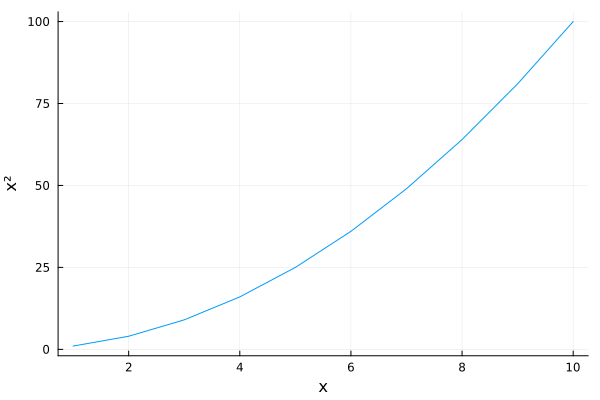

In [15]:
r = 1:10
plot(r, r.^2; label=false, xlabel="x", ylabel="x²")

Il seguente comando disegna un cerchio.

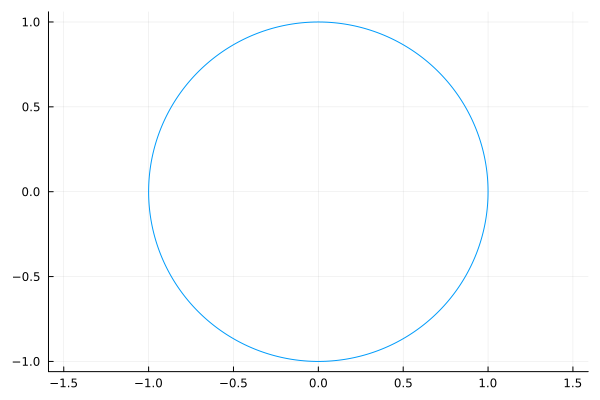

In [16]:
t = range(0, 2π, length=1000)
plot(cos.(t), sin.(t); label=false, aspect_ratio=:equal)

**Suggerimento:** abbiamo già sostituito il comando basato sull'operatore `:` con `range`. Provate a usare `range` nei prossimi esercizi.

### Esercizio 1

Scrivere una funzione `cerchio(z, r)` che, dato un numero complesso `z` e un reale `r ≥ 0`, disegni il cerchio di centro `(real(z), imag(z))` e raggio `r`. Testare con `cerchio(1 + 2im, 2)`. A quale ascissa/ordinata arriva il cerchio?

Per poter riutilizzare la funzione nella sezione seguente, aggiungete la curva al grafico corrente con `plot!`. Per provarla da sola, create prima un grafico vuoto con `plot(aspect_ratio=:equal)`.

In [36]:
# Scrivete qui la funzione cerchio(z, r) e il test richiesto
function cerchio(z, r)
t = range(0, 2π, length=1000)
p= plot!(r*cos.(t).+real(z), r*sin.(t) .+imag(z); label=false, aspect_ratio=:equal)
return p
end

cerchio (generic function with 1 method)

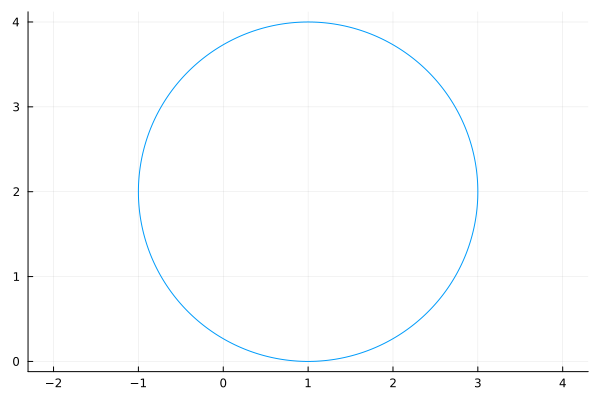

In [26]:
cerchio(1 + 2im, 2)

## 4. Cerchi di Gerschgorin

La seguente funzione disegna gli autovalori e i cerchi di Gerschgorin di una matrice quadrata `A`. La funzione `eigvals`, fornita da `LinearAlgebra`, calcola gli autovalori. `plot!` e `scatter!` aggiungono elementi al grafico corrente.

In [57]:
function gg(A)
    n = size(A, 1)  # cosa fa questa istruzione?

    # Crea un nuovo grafico e forza la stessa scala sui due assi.
    p = plot(; aspect_ratio=:equal, legend=false)

    autovalori = eigvals(A)
    scatter!(p, real.(autovalori), imag.(autovalori);
             marker=:star5, color=:red)
    # :star5 disegna solo i punti, senza collegarli con linee.
    # Usate @doc scatter per conoscere le altre opzioni.
    for k = 1:n
        center = A[k, k]
        radius = 0.0  # accumulatore
        for j = 1:n
            if j != k
                radius = radius + abs(A[k, j])
            end
        end
        cerchio(center, radius)
    end
    return p
end

gg (generic function with 1 method)

### Esercizio 2

Testare la funzione `gg` su alcune matrici: `rand(10, 10)`, `randn(10, 10)` e la matrice di Hilbert di ordine 10, che in Julia possiamo costruire con `[1/(i+j-1) for i=1:10, j=1:10]`.

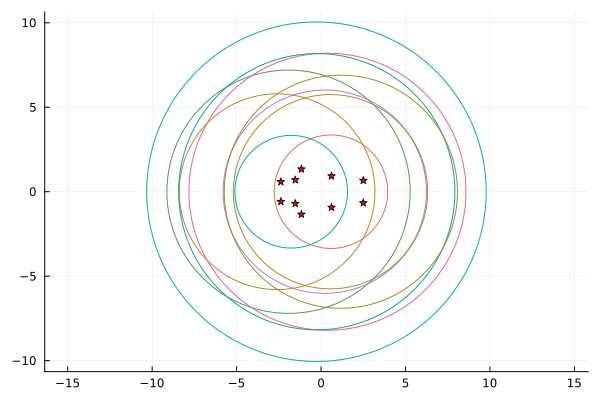

In [52]:
# Scrivete qui i test richiesti
gg(randn(10, 10))

### Esercizio 3

Scrivere una funzione `ggsecond(A)` che disegni i cerchi di Gerschgorin di $A$ e mostri come variano gli autovalori quando gli elementi fuori dalla diagonale di `A` vengono ridotti pian piano fino a diventare zero, come nella dimostrazione del secondo teorema di Gerschgorin. Per farlo, generate tante matrici (diciamo $k=100$) a intervalli uguali lungo il “segmento” che unisce $A$ alla sua diagonale e disegnate i loro autovalori.

In [58]:
# Scrivete qui la funzione ggsecond(A)
function ggsecond(A)
D = zeros(size(A,1), size(A, 2))
for k in 1:size(A,1)
D[k,k]= A[k,k]
end
E = A - D

aut = zeros(100, size(A, 1))
i=1
for t in 0:100:1
At = D + t*E
aut[i,:]= eigvals(At)
i = i+1
end

p = gg(A)

scatter!(p, real(diag(A)), imag(diag(A)), color=:green)
for j in 1:n
plot!(p, real(aut(:,j)), imag(aut(:, j)), color=:black)
end
scatter!(p, real(aut(end, :)), imag(aut(end, :)), color=:red)
return p
end

LoadError: ParseError:
[90m# Error @ [0;0m]8;;file:///content/In[58]#23:22\[90mIn[58]:23:22[0;0m]8;;\
end
scatter!(p, real(aut([48;2;120;70;70m[0;0mend, :)), imag(aut(end, :)), color=:red)
[90m#                    └ ── [0;0m[91mExpected `)` or `,`[0;0m

### Esercizio 4

Nei grafici dell'esercizio precedente noterete che, per molte matrici (fate qualche esempio!), alcuni autovalori si “muovono” secondo questo schema: due autovalori reali si muovono nella stessa direzione e si avvicinano fino a coincidere; poi, una volta uniti, si staccano dall'asse reale e vanno in due direzioni opposte del piano complesso. Verificate questo fenomeno. Sapete spiegare perché accade?

In [ ]:
# Inserite qui gli esperimenti dell'esercizio 4

### Esercizio 5 (facoltativo)

Scrivete una funzione `perturb(A, epsilon)` che, data una matrice $A$, generi 50 matrici i cui elementi sono quelli di $A$ modificati con un valore casuale piccolo, di grandezza circa `epsilon`, ottenibile con le istruzioni `epsilon * (randn(n, n) + im * randn(n, n))`, e disegni i loro autovalori su un grafico.

Di quanto si spostano gli autovalori per una perturbazione di grandezza `epsilon = 1e-2`? Per una matrice casuale? Per l'identità? E per una matrice che ha un singolo blocco di Jordan di dimensione 5?

In [ ]:
# Scrivete qui la funzione perturb(A, epsilon) e i test richiesti

### Esercizio 6 (facoltativo): operazioni vettoriali e cicli

In MATLAB, soprattutto nelle versioni storiche, interpretare ogni singola istruzione aveva un costo non trascurabile. Sostituire operazioni ripetute su scalari con una singola operazione su un vettore — la cosiddetta *vectorization* — permetteva quindi spesso di velocizzare molto i programmi. Per esempio, si preferiva

```matlab
s = sum(abs(v));
```

a un ciclo esplicito con $O(n)$ istruzioni interpretate. Le versioni recenti di MATLAB hanno ridotto questa differenza grazie a un compilatore JIT.

Julia compila le funzioni JIT e i cicli sono normalmente efficienti: non è necessario vettorizzare il codice soltanto per evitare il costo dell'interprete. Le operazioni su interi array rimangono però spesso più concise. In Julia la somma precedente può essere scritta `s = sum(abs, v)`, che applica `abs` agli elementi senza creare un vettore temporaneo.

Riuscite a riscrivere i programmi della scorsa lezione, per esempio `fact` e `myexp2`, usando funzioni che operano su collezioni (`sum`, `prod`, `cumprod`, …) al posto dei cicli `for`? Confrontate chiarezza, allocazioni e tempi delle due versioni. Questa osservazione sarà utile quando affronteremo i cicli annidati per il calcolo delle fattorizzazioni matriciali nelle prossime lezioni.

In [ ]:
# Scrivete qui le versioni basate su operazioni su collezioni